# Notebook 14 — `dist_sink_km` univariate ESDA (L6 + L8)

**Phase 2 of CHAR completion** — spatial autocorrelation for `dist_sink_km`  
(flow distance to marine outlet, km). F4.8 showed this variable is orthogonal  
to all Band A–D variables; this notebook adds the spatial characterisation  
that was missing from the Phase 1 sweep.

DB column: `dist_sink` (already in km; min=0 for sink-adjacent basins).  
Band E (`coastality`), schema_key `dist_sink_km`.

**Conventions**: METH.1–4 — Queen weights `use_index=True`, row-standardised,  
seed=42, 999 permutations, log-transform if skewness > 5, no `plt.show()`,  
-9999 sentinel masked.

In [2]:
# Cell 2 — imports + constants
import time, warnings
import sys
from pathlib import Path

_p = Path.cwd()
while not (_p / 'CLAUDE.md').exists() and _p != _p.parent:
    _p = _p.parent
REPO = _p
sys.path.insert(0, str(REPO))
print(f'REPO = {REPO}')

%matplotlib inline
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely import wkt
from scipy.stats import skew

import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

from scripts.shared.db_utils import db_connect

SEED        = 42
N_PERM      = 999
SIGNIFICANCE = 0.05
NODATA      = -9999
QUAD_MAP    = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
COLOURS     = {'HH': '#d7191c', 'LL': '#2c7bb6', 'HL': '#fdae61', 'LH': '#abd9e9', 'NS': '#e0e0e0'}

CSV_OUT  = REPO / 'spatial' / 'variable_characterization.csv'
PARQ_OUT = REPO / 'output' / 'edop' / 'esda' / 'lisa_classifications.parquet'
IMG_OUT  = REPO / 'spatial'

VAR      = 'dist_sink'
SCHEMA   = 'dist_sink_km'
FRIENDLY = 'Distance to marine outlet'
BAND     = 'E'

def elapsed(t0, label=''):
    m, s = divmod(time.time() - t0, 60)
    print(f'{label}  [{int(m)}m {s:.1f}s]')

print('Imports OK')

REPO = /Users/karlg/Documents/repos/_cedop
Imports OK


## Data loading

Load `dist_sink` at L6 and L8. No scale-factor needed (already km).  
Sentinel check: min=0 (sink-adjacent basins) expected; -9999 should be absent.

In [3]:
# Cell 4 — load L6 and L8
def load_scale(table):
    conn = db_connect()
    sql = f"""
        SELECT hybas_id, dist_sink, ST_AsText(geom) AS geom_wkt
        FROM public.{table}
        ORDER BY hybas_id
    """
    t0 = time.time()
    with conn.cursor() as cur:
        cur.execute(sql)
        rows = cur.fetchall()
    conn.close()
    df = pd.DataFrame(rows, columns=['hybas_id', 'dist_sink', 'geom_wkt'])
    df['geometry'] = df['geom_wkt'].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(df.drop(columns='geom_wkt'), geometry='geometry', crs='EPSG:4326')
    gdf = gdf.set_index('hybas_id')
    elapsed(t0, f'{table} loaded ({len(gdf):,} basins)')
    # sentinel check
    n_sentinel = (gdf['dist_sink'] == NODATA).sum()
    n_null     = gdf['dist_sink'].isna().sum()
    print(f'  sentinel(-9999)={n_sentinel}  null={n_null}  zeros={( gdf["dist_sink"]==0).sum():,}')
    return gdf

gdf6 = load_scale('basin06')
gdf8 = load_scale('basin08')

basin08 loaded (190,675 basins)   8.0s]
  sentinel(-9999)=0  null=0  zeros=26,100


## Distribution check and log-transform decision

Expected: right-skewed (many short coastal-proximity basins, long tail of deeply  
interior continental basins). Per METH.3: log-transform if skewness > 5.

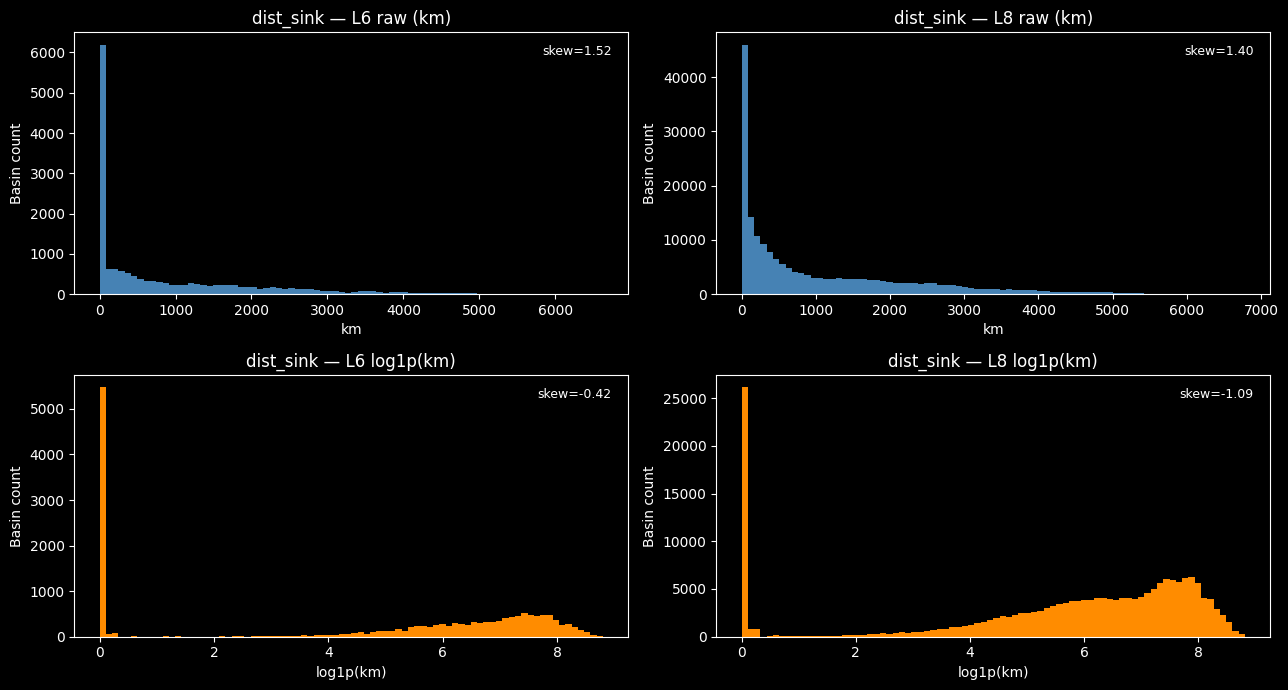

In [4]:
# Cell 6 — distribution plots + skewness decision
v6 = gdf6['dist_sink'].values.astype(float)
v8 = gdf8['dist_sink'].values.astype(float)

for label, v in [('L6', v6), ('L8', v8)]:
    sk = skew(v)
    print(f'{label}: n={len(v):,}  mean={v.mean():.1f}  median={np.median(v):.1f}  '
          f'max={v.max():.1f}  zeros={(v==0).sum():,}  skewness={sk:.2f}  '
          f'→ log_transform={sk > 5}')

v6_log = np.log1p(v6)
v8_log = np.log1p(v8)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, v, title in zip(axes[0], [v6, v8], ['L6 raw (km)', 'L8 raw (km)']):
    ax.hist(v, bins=80, color='steelblue', edgecolor='none')
    ax.set_title(f'dist_sink — {title}')
    ax.set_xlabel('km'); ax.set_ylabel('Basin count')
    ax.text(0.97, 0.95, f'skew={skew(v):.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9)
for ax, v, title in zip(axes[1], [v6_log, v8_log], ['L6 log1p(km)', 'L8 log1p(km)']):
    ax.hist(v, bins=80, color='darkorange', edgecolor='none')
    ax.set_title(f'dist_sink — {title}')
    ax.set_xlabel('log1p(km)'); ax.set_ylabel('Basin count')
    ax.text(0.97, 0.95, f'skew={skew(v):.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9)
plt.tight_layout()

## Queen contiguity weights

Built once at each scale; row-standardised. Reuse across all analyses.

In [5]:
# Cell 8 — Queen weights (L6 and L8)
for label, gdf in [('L6', gdf6), ('L8', gdf8)]:
    t0 = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        w = Queen.from_dataframe(gdf, use_index=True)
    w.transform = 'r'
    elapsed(t0, f'{label} weights: n={w.n:,}  mean_nbrs={w.mean_neighbors:.2f}  islands={len(w.islands)}')
    if label == 'L6':
        w6 = w
    else:
        w8 = w

('WARNING: ', 1080034490.0, ' is an island (no neighbors)')
('WARNING: ', 1080034560.0, ' is an island (no neighbors)')
('WARNING: ', 1080034570.0, ' is an island (no neighbors)')
('WARNING: ', 1080034600.0, ' is an island (no neighbors)')
('WARNING: ', 1080034610.0, ' is an island (no neighbors)')
('WARNING: ', 1080034680.0, ' is an island (no neighbors)')
('WARNING: ', 1080034700.0, ' is an island (no neighbors)')
('WARNING: ', 1080034760.0, ' is an island (no neighbors)')
('WARNING: ', 1080034810.0, ' is an island (no neighbors)')
('WARNING: ', 1080034820.0, ' is an island (no neighbors)')
('WARNING: ', 1080034830.0, ' is an island (no neighbors)')
('WARNING: ', 1080034850.0, ' is an island (no neighbors)')
('WARNING: ', 1080034860.0, ' is an island (no neighbors)')
('WARNING: ', 1080034900.0, ' is an island (no neighbors)')
('WARNING: ', 1080035070.0, ' is an island (no neighbors)')
('WARNING: ', 1080035090.0, ' is an island (no neighbors)')
('WARNING: ', 1080035120.0, ' is an isla

## Global Moran's I — raw and log

Report both; canonical I is raw or log depending on skewness decision above.

In [6]:
# Cell 10 — global Moran's I (L6 and L8, raw and log)
results = {}

for label, v_raw, v_log, w in [('L6', v6, v6_log, w6), ('L8', v8, v8_log, w8)]:
    t0 = time.time()
    np.random.seed(SEED)
    mi_raw = Moran(v_raw, w, permutations=N_PERM)
    np.random.seed(SEED)
    mi_log = Moran(v_log, w, permutations=N_PERM)
    elapsed(t0, f'{label} Moran\'s I computed')
    z_raw = (mi_raw.I - mi_raw.EI) / mi_raw.seI_norm
    z_log = (mi_log.I - mi_log.EI) / mi_log.seI_norm
    print(f"  {label} raw: I={mi_raw.I:.4f}  z={z_raw:.2f}  p={mi_raw.p_norm:.4f}")
    print(f"  {label} log: I={mi_log.I:.4f}  z={z_log:.2f}  p={mi_log.p_norm:.4f}")
    sk = skew(v_raw)
    use_log = sk > 5
    print(f"  canonical: {'log' if use_log else 'raw'}  (skewness={sk:.2f})")
    results[label] = dict(
        mi_raw=mi_raw, mi_log=mi_log,
        I_raw=mi_raw.I, I_log=mi_log.I,
        I_canonical=mi_log.I if use_log else mi_raw.I,
        log_transformed=use_log,
        z_canonical=z_log if use_log else z_raw,
        v_raw=v_raw, v_log=v_log, w=w,
        gdf=gdf6 if label == 'L6' else gdf8
    )

print()
print(f"Scale comparison: L6 I_canonical={results['L6']['I_canonical']:.4f}  "
      f"L8 I_canonical={results['L8']['I_canonical']:.4f}  "
      f"Δ={results['L8']['I_canonical'] - results['L6']['I_canonical']:+.4f}")

L8 Moran's I computed   5.5s]
  L8 raw: I=0.9633  z=701.22  p=0.0000
  L8 log: I=0.8764  z=637.95  p=0.0000
  canonical: raw  (skewness=1.40)

Scale comparison: L6 I_canonical=0.9041  L8 I_canonical=0.9633  Δ=+0.0593


## Moran scatter plots

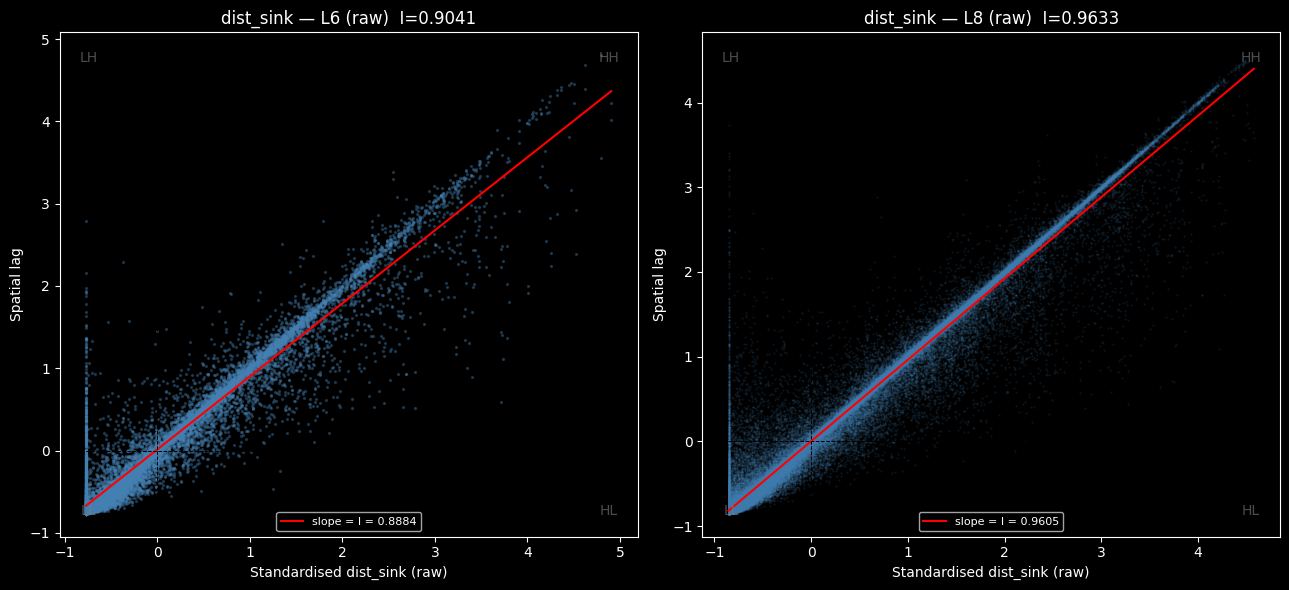

In [7]:
# Cell 12 — Moran scatter plots (L6 and L8, canonical transform)
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, (label, r) in zip(axes, results.items()):
    v_use = r['v_log'] if r['log_transformed'] else r['v_raw']
    v_std = (v_use - v_use.mean()) / v_use.std()
    wv    = libpysal.weights.lag_spatial(r['w'], v_std)
    ax.scatter(v_std, wv, s=0.3 if label == 'L8' else 2,
               alpha=0.15 if label == 'L8' else 0.3,
               color='steelblue', rasterized=True)
    m, b = np.polyfit(v_std, wv, 1)
    x_ln = np.linspace(v_std.min(), v_std.max(), 200)
    ax.plot(x_ln, m * x_ln + b, color='red', linewidth=1.5,
            label=f"slope = I = {m:.4f}")
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.7, linestyle='--')
    for txt, xy in [('HH', (0.95, 0.95)), ('LH', (0.05, 0.95)),
                    ('LL', (0.05, 0.05)), ('HL', (0.95, 0.05))]:
        ax.text(*xy, txt, transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='grey', alpha=0.6)
    tr = 'log1p' if r['log_transformed'] else 'raw'
    ax.set_title(f'dist_sink — {label} ({tr})  I={r["I_canonical"]:.4f}')
    ax.set_xlabel(f'Standardised dist_sink ({tr})')
    ax.set_ylabel('Spatial lag')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(IMG_OUT / '14_dist_sink_scatter.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/14_dist_sink_scatter.png')

## LISA — Local Moran's I (canonical transform)

Classes: HH (far-from-sink clusters), LL (near-sink coastal clusters),  
HL (far outlier in near surroundings), LH (near outlier in far surroundings).  
p < 0.05 threshold.

In [8]:
# Cell 14 — LISA (L6 and L8)
for label, r in results.items():
    v_use = r['v_log'] if r['log_transformed'] else r['v_raw']
    t0 = time.time()
    np.random.seed(SEED)
    lisa = Moran_Local(v_use, r['w'], permutations=N_PERM, seed=SEED)
    elapsed(t0, f'LISA {label}')

    labels = np.where(
        lisa.p_sim < SIGNIFICANCE,
        np.array([QUAD_MAP[q] for q in lisa.q]),
        'NS'
    )
    r['gdf']['lisa_class'] = labels
    r['gdf']['lisa_p']     = lisa.p_sim
    r['gdf']['lisa_I']     = lisa.Is
    r['gdf']['lisa_quad']  = lisa.q
    r['lisa'] = lisa
    r['labels'] = labels

    n = len(r['gdf'])
    counts = pd.Series(labels).value_counts().reindex(['HH','LL','HL','LH','NS'], fill_value=0)
    print(f'\nLISA {label} (p < {SIGNIFICANCE}):')
    for cls, cnt in counts.items():
        print(f'  {cls}: {cnt:7,}  ({cnt/n*100:.1f}%)')

/Users/karlg/venvs/cedop/lib/python3.14/site-packages/esda/moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


## LISA cluster maps

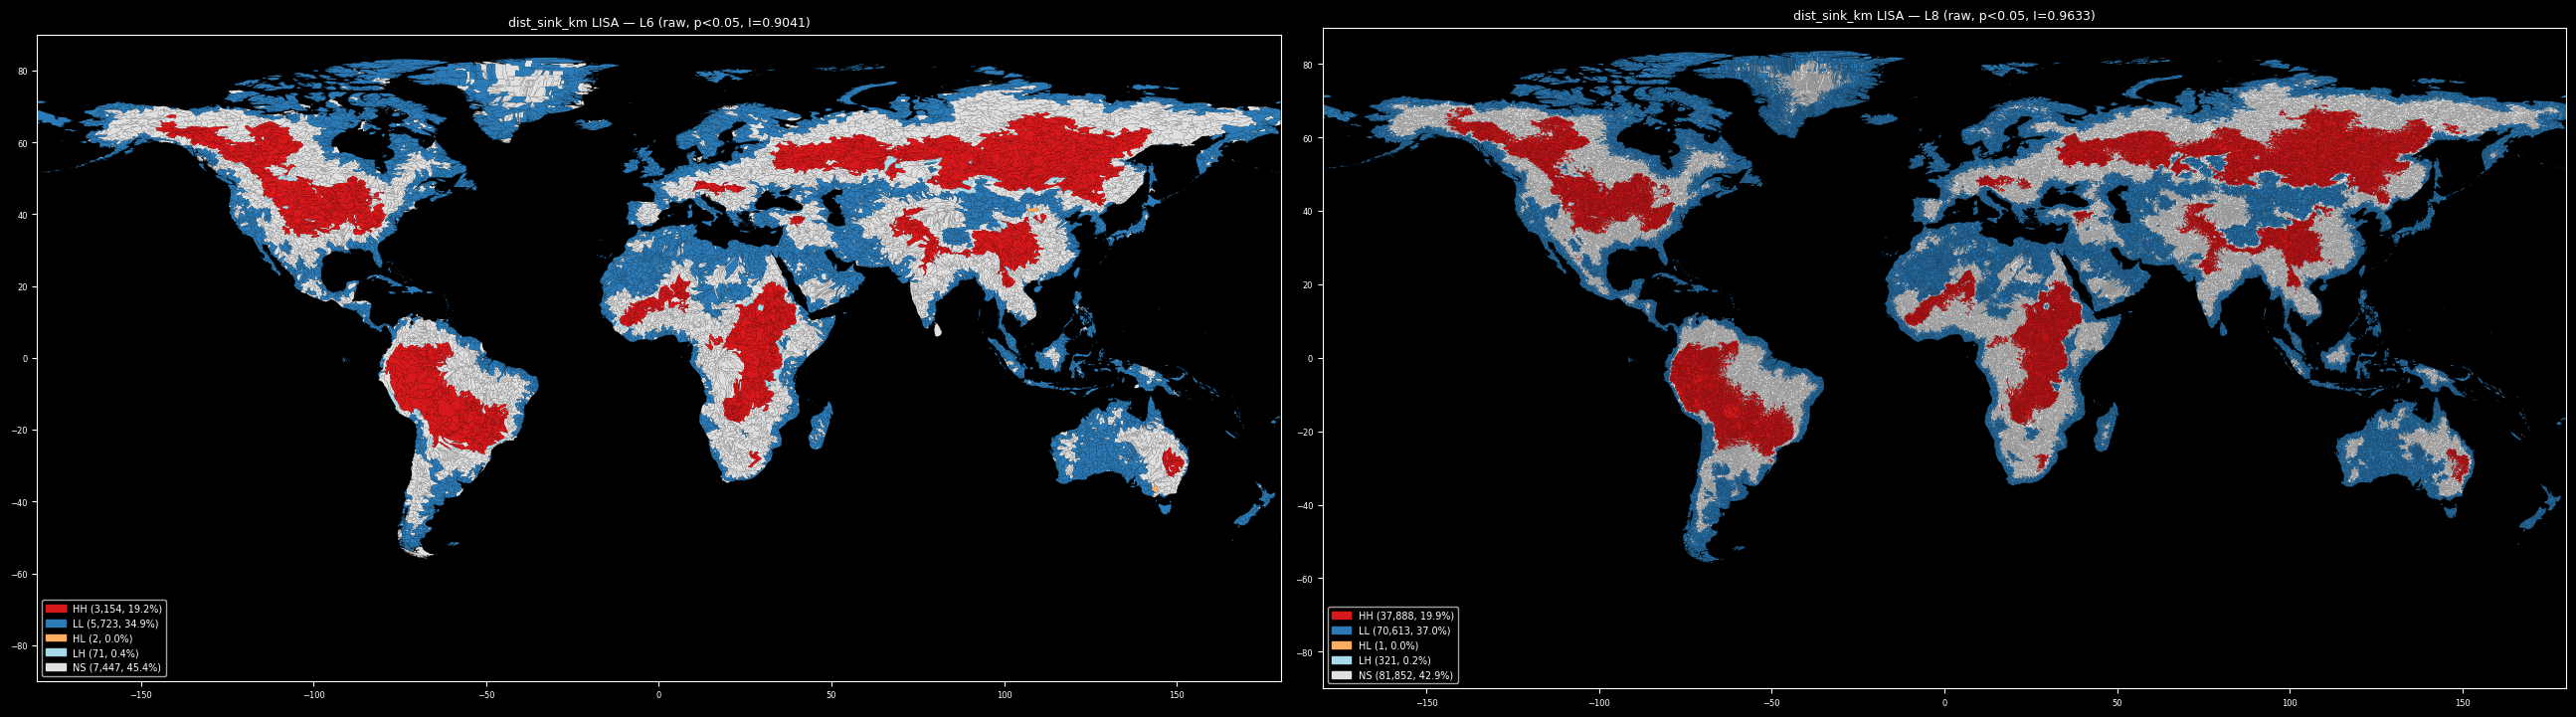

In [9]:
# Cell 16 — LISA cluster maps (L6 and L8 side by side)
fig, axes = plt.subplots(1, 2, figsize=(26, 7))

for ax, (label, r) in zip(axes, results.items()):
    gdf = r['gdf']
    gdf[gdf['lisa_class'] == 'NS'].plot(ax=ax, color=COLOURS['NS'], linewidth=0)
    for cls in ['LL', 'HH', 'HL', 'LH']:
        sub = gdf[gdf['lisa_class'] == cls]
        if len(sub):
            sub.plot(ax=ax, color=COLOURS[cls], linewidth=0)

    n = len(gdf)
    counts = gdf['lisa_class'].value_counts().reindex(['HH','LL','HL','LH','NS'], fill_value=0)
    handles = [
        mpatches.Patch(color=COLOURS[cls],
                       label=f"{cls} ({counts[cls]:,}, {counts[cls]/n*100:.1f}%)")
        for cls in ['HH','LL','HL','LH','NS'] if counts[cls] > 0
    ]
    ax.legend(handles=handles, loc='lower left', fontsize=7, framealpha=0.8)
    tr = 'log1p' if r['log_transformed'] else 'raw'
    ax.set_title(f'dist_sink_km LISA — {label} ({tr}, p<0.05, I={r["I_canonical"]:.4f})',
                 fontsize=9)
    ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig(IMG_OUT / '14_dist_sink_lisa.png', dpi=150, bbox_inches='tight')
print('Saved → spatial/14_dist_sink_lisa.png')

## Append outputs

One row per (variable, scale) appended to `spatial/variable_characterization.csv`.  
Per-basin LISA appended to `output/edop/esda/lisa_classifications.parquet`.

In [10]:
# Cell 18 — append to variable_characterization.csv and lisa_classifications.parquet
from scipy.stats import kurtosis

csv_rows = []
lisa_rows = []

for label, r in results.items():
    v = r['v_raw']
    mi_raw = r['mi_raw']
    mi_log = r['mi_log']
    gdf    = r['gdf']
    n      = len(gdf)
    counts = pd.Series(r['labels']).value_counts().reindex(['HH','LL','HL','LH','NS'], fill_value=0)

    z_raw = (mi_raw.I - mi_raw.EI) / mi_raw.seI_norm
    z_log = (mi_log.I - mi_log.EI) / mi_log.seI_norm
    z_can = z_log if r['log_transformed'] else z_raw

    csv_rows.append(dict(
        variable=VAR, schema_key=SCHEMA, friendly_name=FRIENDLY, band=BAND, scale=label,
        mean=round(float(v.mean()), 4),
        median=round(float(np.median(v)), 4),
        std=round(float(v.std()), 4),
        min=round(float(v.min()), 4),
        max=round(float(v.max()), 4),
        skewness=round(float(skew(v)), 4),
        kurtosis=round(float(kurtosis(v)), 4),
        zero_fraction=round(float((v == 0).mean()), 6),
        missing_pct=round(float(np.isnan(v).mean() * 100), 4),
        n_basins=n,
        log_transformed=r['log_transformed'],
        I_raw=round(r['I_raw'], 6),
        I_log=round(r['I_log'], 6),
        I_canonical=round(r['I_canonical'], 6),
        p_value=round(mi_log.p_sim if r['log_transformed'] else mi_raw.p_sim, 4),
        z_score=round(float(z_can), 4),
        n_HH=int(counts['HH']),  pct_HH=round(counts['HH']/n*100, 2),
        n_LL=int(counts['LL']),  pct_LL=round(counts['LL']/n*100, 2),
        n_HL=int(counts['HL']),  pct_HL=round(counts['HL']/n*100, 2),
        n_LH=int(counts['LH']),  pct_LH=round(counts['LH']/n*100, 2),
        n_NS=int(counts['NS']),  pct_NS=round(counts['NS']/n*100, 2),
        cluster_core_pct=round((counts['HH'] + counts['LL']) / n * 100, 2),
        outlier_pct=round((counts['HL'] + counts['LH']) / n * 100, 2),
        seed=SEED,
        n_permutations=N_PERM,
    ))

    # per-basin LISA rows
    lisa_df = pd.DataFrame({
        'variable': VAR,
        'scale':    label,
        'hybas_id': gdf.index.values,
        'lisa_class': r['labels'],
        'p_value':  r['lisa'].p_sim,
        'local_I':  r['lisa'].Is,
        'quad':     r['lisa'].q,
    })
    lisa_rows.append(lisa_df)

# --- append CSV ---
new_csv = pd.DataFrame(csv_rows)
existing = pd.read_csv(CSV_OUT)
# drop if already present (safe re-run)
existing = existing[~((existing['variable'] == VAR))]
updated = pd.concat([existing, new_csv], ignore_index=True)
updated.to_csv(CSV_OUT, index=False)
print(f'CSV: {CSV_OUT.name}  ({len(updated)} rows, was {len(existing)})')

# --- append parquet ---
new_parq = pd.concat(lisa_rows, ignore_index=True)
existing_parq = pd.read_parquet(PARQ_OUT)
existing_parq = existing_parq[existing_parq['variable'] != VAR]
updated_parq = pd.concat([existing_parq, new_parq], ignore_index=True)
updated_parq.to_parquet(PARQ_OUT, index=False)
print(f'Parquet: {PARQ_OUT.name}  ({len(updated_parq):,} rows, added {len(new_parq):,})')
print(f'\nNew rows in CSV:')
print(new_csv[['variable','scale','skewness','log_transformed','I_raw','I_log',
               'I_canonical','p_value','pct_HH','pct_LL','pct_HL','pct_LH','pct_NS']].to_string(index=False))

Parquet: lisa_classifications.parquet  (7,834,072 rows, added 207,072)

New rows in CSV:
 variable scale  skewness  log_transformed    I_raw    I_log  I_canonical  p_value  pct_HH  pct_LL  pct_HL  pct_LH  pct_NS
dist_sink    L6    1.5187            False 0.904075 0.801691     0.904075    0.001   19.24   34.90    0.01    0.43   45.42
dist_sink    L8    1.3957            False 0.963339 0.876416     0.963339    0.001   19.87   37.03    0.00    0.17   42.93


## Summary findings — dist_sink_km ESDA

---

### DSK.1 — Global Moran's I: dist_sink_km

| Scale | I_raw | I_log | I_canonical | transform | p | z |
|---|---|---|---|---|---|---|
| L6 | 0.9041 | 0.8017 | 0.9041 | raw | 0.001 | 187.27 |
| L8 | 0.9633 | 0.8764 | 0.9633 | raw | 0.001 | 701.22 |

Canonical transform: raw at both scales (skewness 1.52 / 1.40, both below the threshold of 5).
Raw I > log I — unusual. log1p compresses the large interior values (e.g. 5000 km → 8.5)
relative to coastal zeros, making the spatial gradient appear less steep. The variable's
moderate skewness means the raw spatial structure is stronger than log would suggest.

---

### DSK.2 — Scale comparison: continental-gradient tier, scale-stable

Δ = +0.059 (L6 → L8, direction ↑). Consistent with the continental-gradient group
from the Phase 1 typology. dist_sink_km is the most scale-stable variable in the sweep:
the LISA map is geographically indistinguishable at L6 and L8. NS shrinks from 45.4% → 42.9%
as more basins resolve into their cluster, but no new geographic structure appears.
This contrasts with climate variables (which tighten at L8) and discharge (which shifts
direction). dist_sink is essentially a geometric coordinate; its spatial pattern is fixed
at the continental scale captured by L6.

---

### DSK.3 — LISA class distribution

| Class | L6 n | L6 % | L8 n | L8 % |
|---|---|---|---|---|
| HH | 3,154 | 19.24 | 37,888 | 19.87 |
| LL | 5,723 | 34.90 | 70,613 | 37.03 |
| HL | 2 | 0.01 | 1 | 0.00 |
| LH | 71 | 0.43 | 321 | 0.17 |
| NS | 7,447 | 45.42 | 81,852 | 42.93 |

LL > HH at both scales: coastal margins cover more basin area than deep continental interiors.

HL near-zero (2 basins L6, 1 basin L8): physically near-impossible. A far-interior basin
cannot be surrounded by coastal basins — the spatial gradient is monotonic. The near-zero
HL fraction is itself a diagnostic finding: dist_sink has no spatial anomalies in the
continental-interior direction.

LH small and decreasing (0.43% → 0.17%): near-sink basins embedded in interior terrain —
fjord-fed inlets, river mouths penetrating plateaus, coastal enclaves. LH% decreases at L8
as coastal tessellation tightens and these enclaves are surrounded by other coastal basins.

Cluster core (HH+LL): 54.1% (L6) / 56.9% (L8) — among the highest in the 40-variable
sweep, alongside climate variables. Most of the globe is inside a significant cluster.

Outlier fraction (HL+LH): 0.44% (L6) / 0.17% (L8) — lowest in the dataset.

---

### DSK.4 — Implication for EDOPS

dist_sink_km is a geographic-position variable: it encodes continental position relative
to the ocean, not a physical environmental process. This explains its orthogonality to
Band A–D variables (F4.8) — it adds independent geographic context that none of the
physical variables capture.

The near-zero HL fraction has a direct slider implication: selecting high dist_sink_km
is implicitly selecting deep-continental basins, and vice versa. The variable functions
as a continent-interior / coastal-margin switch with no ambiguity.

Historical validity: stable on geological timescales. Ocean geometry and continental
positions do not change on the timescales of interest to EDOPS users.

Typology assignment: continental-gradient (I_L6=0.904, scale ↑, outlier%=0.44%).